In [40]:
%pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:
### CONFIGURATION ###
# Data
csv_file = 'pfp_b200_add_u64_sweep.csv'
word_size = 64;
add_or_contains = 'Add'

# Machine
l2_bytes = 100 * 1024 * 1024
l1_bytes = 256 * 1024
### END CONFIGURATION ###

In [42]:
# Data preparation
df = pd.read_csv(csv_file)
df['AddThroughput(GK/s)'] = df['Elem/s (elem/sec)'] / (1024 * 1024 * 1024)
df['Log2FilterBytes'] = df['FilterSizeMB'].apply(
    lambda x: math.log2(x * 1024 * 1024))
df = df[(df['BlockBits'] >= word_size) & (df['Skipped'] == 'No')]
df['VectorizationConfig'] = df.apply(
    lambda row: f"H={row['HorizontalLayout']}, V={row['VerticalLayout']}", 
    axis=1)
max_log_filter_size = int(df['Log2FilterBytes'].max())
min_log_filter_size = int(df['Log2FilterBytes'].min())

df_small_k = df[df['PatternBitsPerWord'] == 1]
df_large_k = df[df['PatternBitsPerWord'] == 20]

block_sizes = sorted(df['BlockBits'].unique())

machine = df['Device Name'].iloc[0]
log_l2_bytes = math.log2(l2_bytes)
log_l1_bytes = math.log2(l1_bytes)

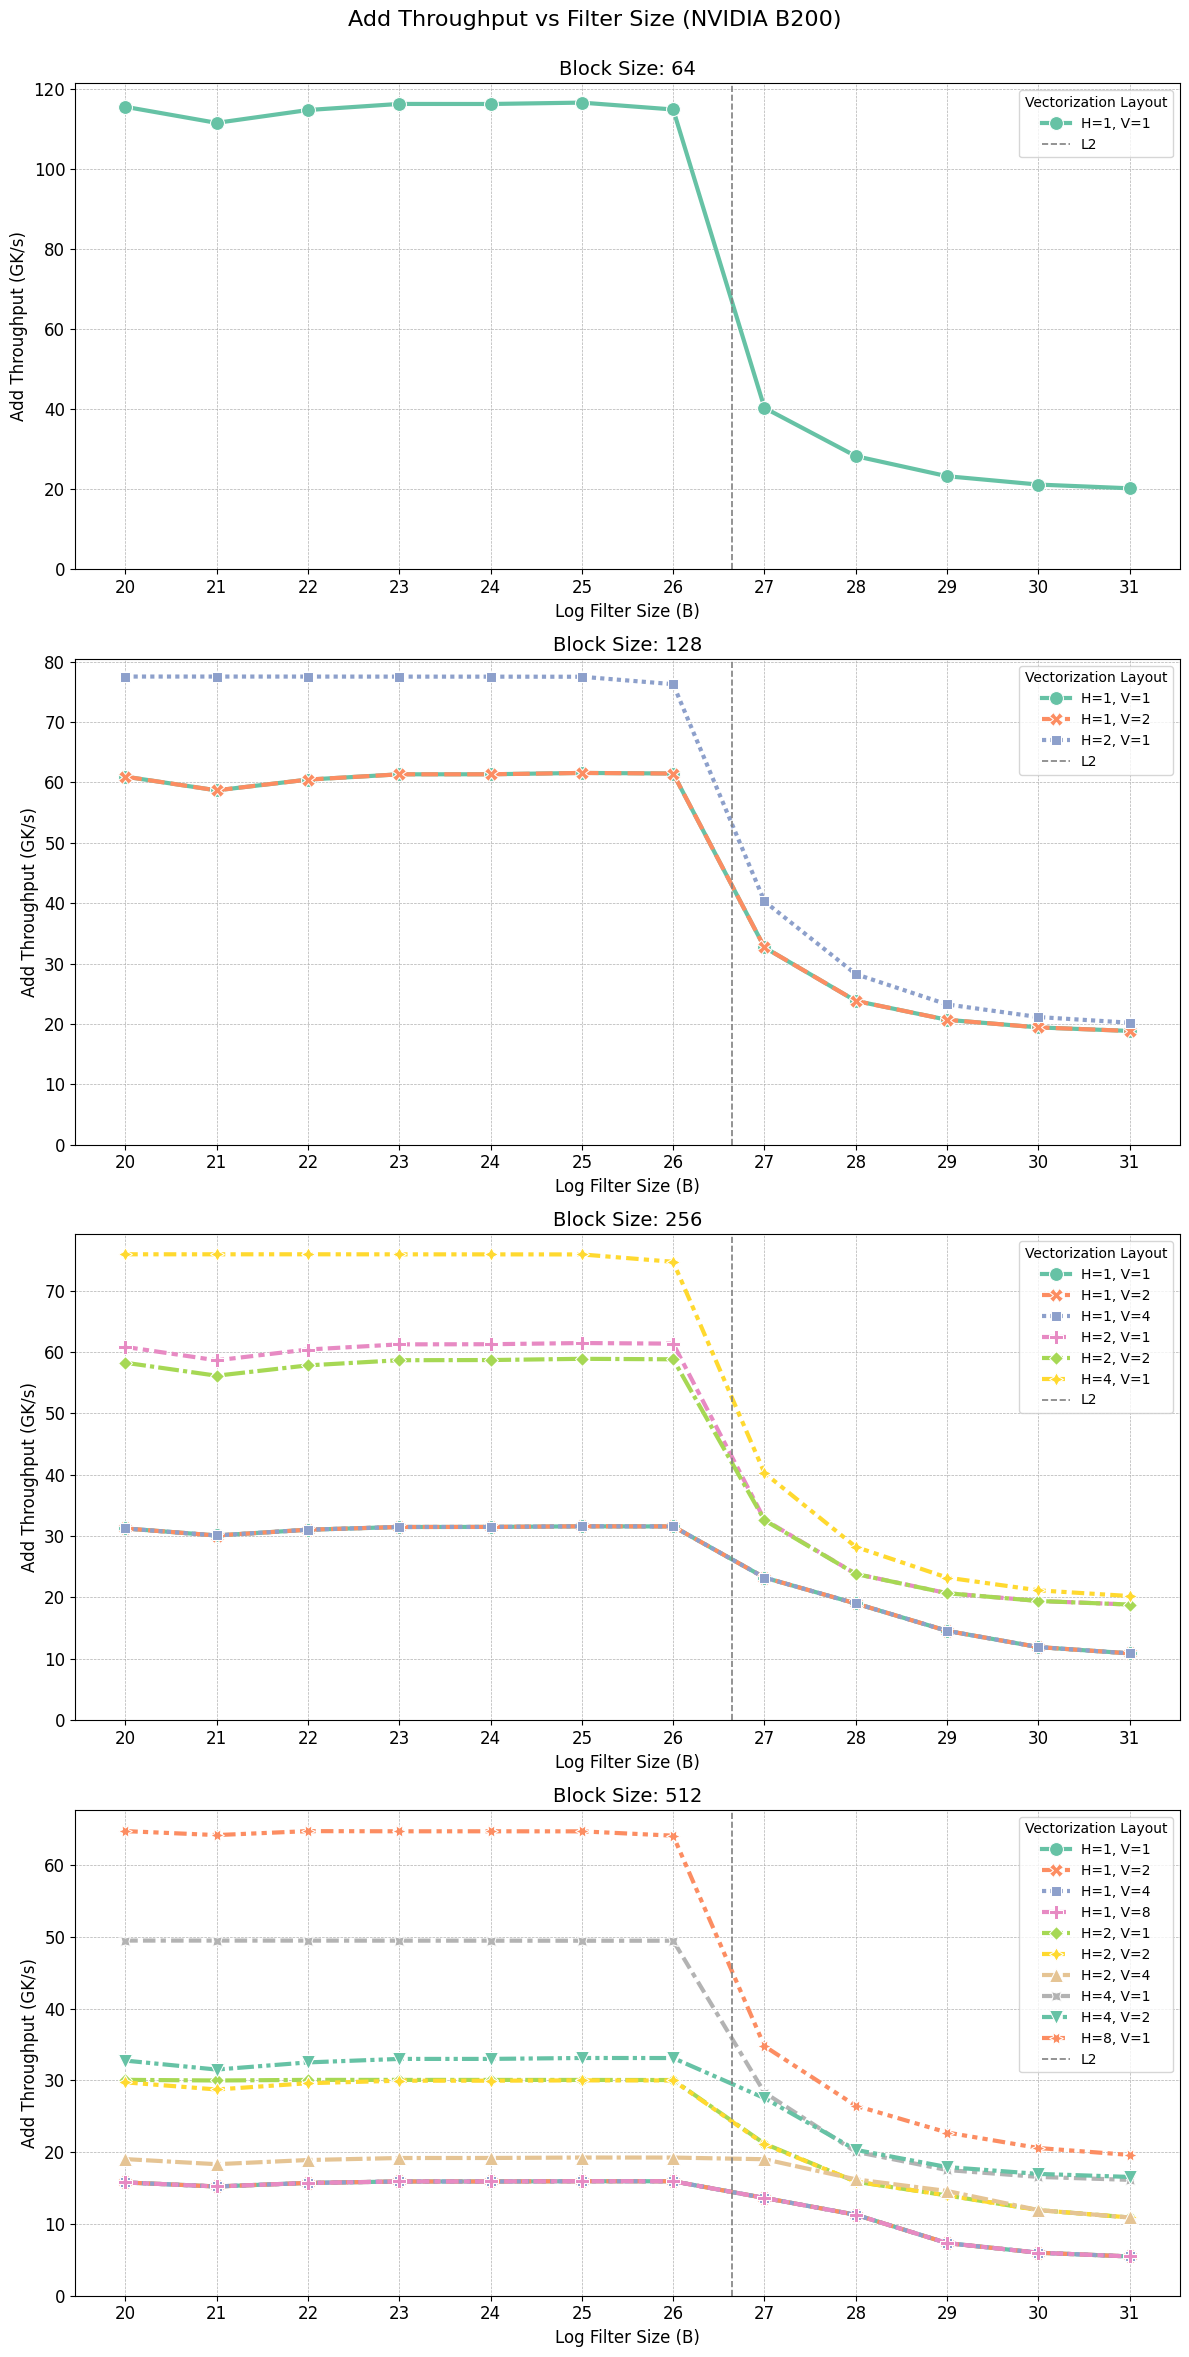

In [44]:
# k = WordsPerBlock plot
fig, axes = plt.subplots(len(block_sizes),
                         figsize=(12, 6 * len(block_sizes)),
                         sharex=False,
                         sharey=False)
for i, block_size in enumerate(block_sizes):
    subset = df_small_k[df_small_k['BlockBits'] == block_size]
    combinations = subset['VectorizationConfig'].drop_duplicates()
    palette = sns.color_palette(
        'Set2', n_colors=len(combinations))
    sns.lineplot(
        data=subset,
        x='Log2FilterBytes',
        y='AddThroughput(GK/s)',
        hue='VectorizationConfig',
        style='VectorizationConfig',
        markers=True,
        ax=axes[i],
        palette=palette,
        linewidth=3,
        markersize=10)
    axes[i].axvline(log_l2_bytes, color='gray',
                    linestyle='--', label='L2', linewidth=1.2)
    axes[i].set_title(f'Block Size: {block_size}', fontsize=14)
    axes[i].set_ylabel(f'{add_or_contains} Throughput (GK/s)', fontsize=12)
    axes[i].set_xticks(range(min_log_filter_size, max_log_filter_size + 1))
    axes[i].set_xlabel('Log Filter Size (B)', fontsize=12)
    axes[i].set_ylim(bottom=0)
    axes[i].tick_params(axis='both', labelsize=12)
    axes[i].grid(True, linestyle='--', linewidth=0.5)
    axes[i].legend(title='Vectorization Layout', loc='upper right')

fig.suptitle(f"{add_or_contains} Throughput vs Filter Size ({machine})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()